# H2 — Religious Amplification: Statistical Tests & Model 2

**Hypothesis:** The gender gap in W−C asymmetry is *larger* in religious-themed artworks than in secular artworks.

**Plan:**
1. Descriptive: 2×2 group means (Gender × Context) + interaction plot
2. Statistical tests: Two-way ANOVA, simple effects, effect sizes per subgroup
3. Model 2: `Asymmetry_i = β₀ + β₁·Female_i + β₂·Religious_i + β₃·(Female×Religious)_i + ε_i`
4. Robustness: Warmth and Competence as separate DVs
5. Subfacet breakdown: which SADCAT dimensions drive the pattern?
6. Religious sub-genre analysis: asymmetry within saints, NT, Virgin, etc.
7. Within-artwork paired analysis split by context
8. Sensitivity: coverage filter + century control
9. Clustered SEs by artwork

**Date:** March 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import re
import warnings
warnings.filterwarnings('ignore')

# ── Style (consistent with prior notebooks) ──
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS     = {"Male": "#6dc985", "Female": "#4f2478"}
CTX_COLORS = {"religious": "#660033", "secular": "#B8C4BB"}
DPI = 150
from pathlib import Path
FIG_DIR = Path("../figures")

def savefig(fig, name):
    try:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=DPI, bbox_inches="tight", facecolor="white")
        print(f"  Saved: ../figures/{name}.png")
    except Exception:
        pass

def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1-1)*g1.var() + (n2-1)*g2.var()) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Load data ──
df = pd.read_csv("/Users/marevi/Downloads/analysis_copy/analysis_dataset.csv")

# Filter to Male/Female, create binary indicators
dfa = df[df["gender"].isin(["Male", "Female"])].copy()
dfa["female"]   = (dfa["gender"]   == "Female").astype(int)
dfa["religious"] = (dfa["context"] == "religious").astype(int)

# Parse century for later controls
def parse_century(val):
    if pd.isna(val): return None
    m = re.match(r"(\d+)", str(val).strip())
    return int(m.group(1)) if m else None

dfa["century_num"] = dfa["century"].apply(parse_century)

# SADCAT subfacets
SUBFACETS = ["Warmth", "Competence", "Sociability", "Morality",
             "Ability", "Assertiveness", "Status", "Beliefs", "Religion", "Politics"]

print(f"Analysis set: {len(dfa):,} figures")
print(f"  Religious: {dfa['religious'].sum():,}  |  Secular: {(dfa['religious']==0).sum():,}")
print(f"  Male:      {(dfa['female']==0).sum():,}  |  Female:   {dfa['female'].sum():,}")
print()
print("2×2 cell counts:")
print(dfa.groupby(["context", "gender"]).size().unstack())

Analysis set: 18,761 figures
  Religious: 7,750  |  Secular: 11,011
  Male:      12,005  |  Female:   6,756

2×2 cell counts:
gender     Female  Male
context                
religious    2683  5067
secular      4073  6938


---
## 1. Descriptive: 2×2 Means and Interaction Plot

In [3]:
# ── 1a. 2×2 summary table ──
summary_2x2 = dfa.groupby(["context", "gender"]).agg(
    n=("cat_no", "count"),
    warmth_mean=("dirmean_Warmth", "mean"),
    warmth_sd=("dirmean_Warmth", "std"),
    competence_mean=("dirmean_Competence", "mean"),
    competence_sd=("dirmean_Competence", "std"),
    asymmetry_mean=("asymmetry", "mean"),
    asymmetry_sd=("asymmetry", "std"),
).round(4)

print("=" * 70)
print("2×2 Descriptive Statistics: Context × Gender")
print("=" * 70)
display(summary_2x2)

# Gender gaps per context
print("\nGender gap (Female − Male) per context:")
for ctx in ["religious", "secular"]:
    m = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Male")]
    f = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Female")]
    for col, label in [("asymmetry", "Asymmetry"), ("dirmean_Warmth", "Warmth"), ("dirmean_Competence", "Competence")]:
        gap = f[col].mean() - m[col].mean()
        print(f"  {ctx.capitalize():10s} | {label:12s}: {gap:+.4f}")

2×2 Descriptive Statistics: Context × Gender


n  warmth_mean  warmth_sd  competence_mean  \
context   gender                                                  
religious Female  2683       0.5358     0.3214           0.5284   
          Male    5067       0.4077     0.3916           0.5350   
secular   Female  4073       0.4375     0.4059           0.4893   
          Male    6938       0.3194     0.4333           0.6190   

                  competence_sd  asymmetry_mean  asymmetry_sd  
context   gender                                               
religious Female         0.4224         -0.0021        0.4882  
          Male           0.4373         -0.1353        0.5526  
secular   Female         0.4341         -0.0667        0.5235  
          Male           0.3862         -0.3078        0.5350


Gender gap (Female − Male) per context:
  Religious  | Asymmetry   : +0.1332
  Religious  | Warmth      : +0.1281
  Religious  | Competence  : -0.0065
  Secular    | Asymmetry   : +0.2411
  Secular    | Warmth      : +0.1181
  Secular    | Competence  : -0.1297


  Saved: ../figures/h2_01_interaction_plot.png


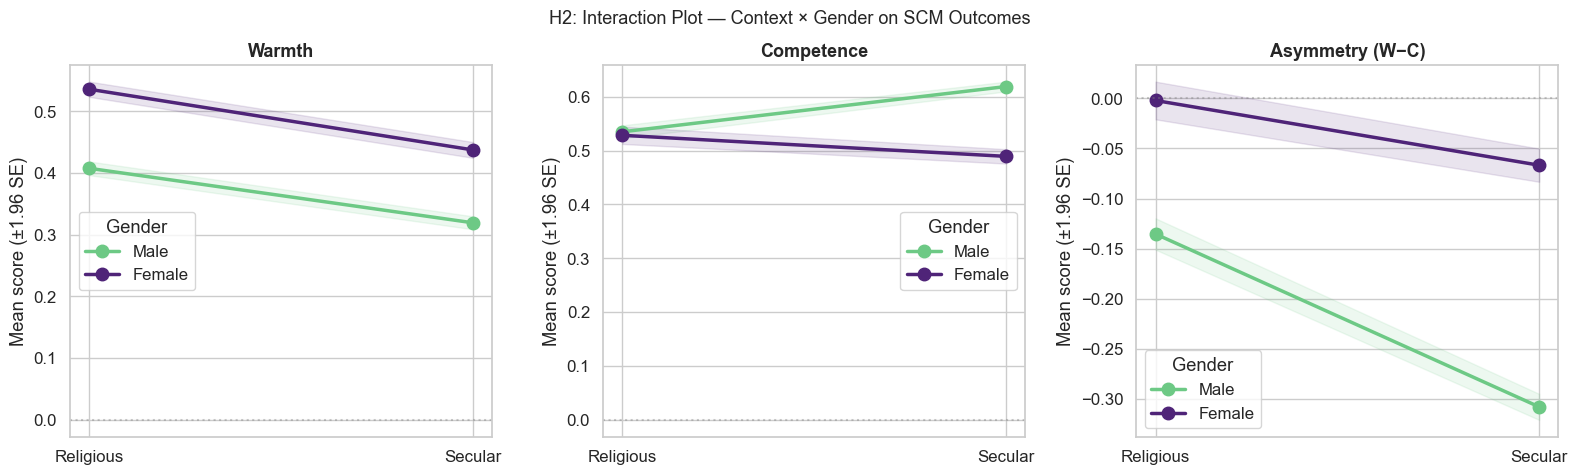


Key question: Do the Male/Female lines DIVERGE across contexts?
Diverging lines = interaction effect = religious amplification.


In [10]:
# ── 1b. Interaction plots: Warmth, Competence, Asymmetry ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outcomes_plot = [
    ("dirmean_Warmth",    "Warmth"),
    ("dirmean_Competence","Competence"),
    ("asymmetry",         "Asymmetry (W−C)"),
]
x_order = ["religious", "secular"]
x_labels = ["Religious", "Secular"]

for ax, (col, title) in zip(axes, outcomes_plot):
    for g in ["Male", "Female"]:
        means = [dfa[(dfa["context"]==ctx) & (dfa["gender"]==g)][col].mean() for ctx in x_order]
        sems  = [dfa[(dfa["context"]==ctx) & (dfa["gender"]==g)][col].sem()  for ctx in x_order]
        ax.plot(x_labels, means, "o-", color=COLORS[g], lw=2.5, ms=9, label=g)
        ax.fill_between(x_labels,
                        [m - 1.96*s for m, s in zip(means, sems)],
                        [m + 1.96*s for m, s in zip(means, sems)],
                        color=COLORS[g], alpha=0.12)

    ax.axhline(0, color="gray", ls=":", alpha=0.4)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean score (±1.96 SE)")
    ax.legend(title="Gender")

plt.suptitle("H2: Interaction Plot — Context × Gender on SCM Outcomes",
             fontsize=13, y=0.95)
plt.tight_layout()
savefig(fig, "h2_01_interaction_plot")
plt.show()

print("\nKey question: Do the Male/Female lines DIVERGE across contexts?")
print("Diverging lines = interaction effect = religious amplification.")

---
## 2. Statistical Tests: Two-Way ANOVA + Simple Effects

In [11]:
# ── 2a. Two-way ANOVA: Gender × Context on Asymmetry ──
# Using Type III SS (tests each effect controlling for others)

anova_model = smf.ols("asymmetry ~ C(gender) * C(context)", data=dfa).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=3)

print("=" * 60)
print("Two-Way ANOVA (Type III SS): Asymmetry ~ Gender × Context")
print("=" * 60)
print(anova_table.round(4))

# Eta-squared (effect size for ANOVA)
ss_total = anova_table["sum_sq"].sum()
print("\nPartial η² (effect sizes):")
for term in anova_table.index:
    if term != "Residual":
        eta2 = anova_table.loc[term, "sum_sq"] / ss_total
        print(f"  {term:35s}: η² = {eta2:.4f}")

Two-Way ANOVA (Type III SS): Asymmetry ~ Gender × Context
                         sum_sq       df         F  PR(>F)
Intercept                0.0116      1.0    0.0412  0.8392
C(gender)               29.8588      1.0  105.9590  0.0000
C(context)               6.4560      1.0   22.9101  0.0000
C(gender):C(context)    11.5650      1.0   41.0403  0.0000
Residual              5007.2372  17769.0       NaN     NaN

Partial η² (effect sizes):
  Intercept                          : η² = 0.0000
  C(gender)                          : η² = 0.0059
  C(context)                         : η² = 0.0013
  C(gender):C(context)               : η² = 0.0023


In [62]:
# ── 2b. Simple effects: gender difference WITHIN each context ──
print("=" * 70)
print("SIMPLE EFFECTS: Gender difference within each context")
print("=" * 70)

simple_rows = []
for ctx in ["religious", "secular"]:
    m = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Male")]["asymmetry"].dropna()
    f = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Female")]["asymmetry"].dropna()

    t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(f, m, alternative="two-sided")
    d = cohens_d(f, m)

    # CI on mean diff
    se = np.sqrt(f.var()/len(f) + m.var()/len(m))
    df_w = (f.var()/len(f) + m.var()/len(m))**2 / ((f.var()/len(f))**2/(len(f)-1) + (m.var()/len(m))**2/(len(m)-1))
    t_c = stats.t.ppf(0.975, df=df_w)
    diff = f.mean() - m.mean()
    ci_lo, ci_hi = diff - t_c*se, diff + t_c*se

    simple_rows.append({
        "Context": ctx.capitalize(),
        "n_female": len(f), "mean_female": f.mean(),
        "n_male":   len(m), "mean_male":   m.mean(),
        "diff (F-M)": diff, "CI_lo": ci_lo, "CI_hi": ci_hi,
        "Cohen's d": d,
        "Welch t": t_stat, "p (Welch)": t_p,
        "Mann-Whitney p": u_p,
    })

    print(f"\n  {ctx.upper()}:")
    print(f"    Female: mean={f.mean():.4f} (n={len(f):,})")
    print(f"    Male:   mean={m.mean():.4f} (n={len(m):,})")
    print(f"    Δ (F−M) = {diff:+.4f}  [95% CI: {ci_lo:+.4f}, {ci_hi:+.4f}]")
    print(f"    Cohen's d = {d:+.4f}  |  Welch t = {t_stat:.3f}, p = {t_p:.3e} {sig_stars(t_p)}")
    print(f"    Mann-Whitney p = {u_p:.3e} {sig_stars(u_p)}")

df_simple = pd.DataFrame(simple_rows).set_index("Context")

# Key comparison: is the gap larger in religious vs secular?
rel_gap = df_simple.loc["Religious", "diff (F-M)"]
sec_gap = df_simple.loc["Secular",   "diff (F-M)"]
print(f"\n{'='*60}")
print(f"Gender gap in Religious: {rel_gap:+.4f}")
print(f"Gender gap in Secular:   {sec_gap:+.4f}")
print(f"Amplification (Rel − Sec): {rel_gap - sec_gap:+.4f}")

SIMPLE EFFECTS: Gender difference within each context

  RELIGIOUS:
    Female: mean=-0.0021 (n=2,590)
    Male:   mean=-0.1353 (n=4,805)
    Δ (F−M) = +0.1332  [95% CI: +0.1087, +0.1577]
    Cohen's d = +0.2509  |  Welch t = 10.679, p = 2.217e-26 ***
    Mann-Whitney p = 1.375e-27 ***

  SECULAR:
    Female: mean=-0.0667 (n=3,850)
    Male:   mean=-0.3078 (n=6,528)
    Δ (F−M) = +0.2411  [95% CI: +0.2201, +0.2621]
    Cohen's d = +0.4543  |  Welch t = 22.483, p = 1.111e-108 ***
    Mann-Whitney p = 1.391e-107 ***

Gender gap in Religious: +0.1332
Gender gap in Secular:   +0.2411
Amplification (Rel − Sec): -0.1079


  Saved: ../figures/h2_02_simple_effects_forest.png


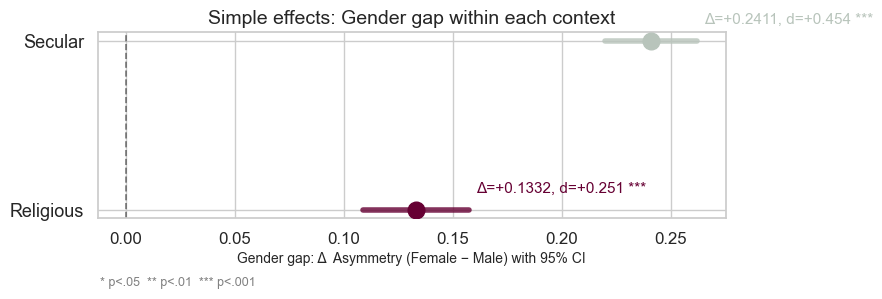

In [55]:
# ── 2c. Simple effects forest plot ──
fig, ax = plt.subplots(figsize=(9, 3.5))

contexts = ["Religious", "Secular"]
ctx_colors = [CTX_COLORS["religious"], CTX_COLORS["secular"]]

for i, (ctx, color) in enumerate(zip(contexts, ctx_colors)):
    row = df_simple.loc[ctx]
    diff = row["diff (F-M)"]
    lo, hi = row["CI_lo"], row["CI_hi"]
    d = row["Cohen's d"]
    p = row["p (Welch)"]

    ax.plot([lo, hi], [i, i], lw=4, color=color, alpha=0.8, solid_capstyle="round")
    ax.plot(diff, i, "o", ms=12, color=color, zorder=5)
    ax.text(hi + 0.003, i + 0.10,
            f"Δ={diff:+.4f}, d={d:+.3f} {sig_stars(p)}",
            fontsize=11, color=color)

ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(contexts, fontsize=13)
ax.set_xlabel("Gender gap: Δ  Asymmetry (Female − Male) with 95% CI", fontsize=10)
ax.set_title("Simple effects: Gender gap within each context",
             fontsize=14)
ax.text(ax.get_xlim()[0] + 0.001, -0.45,
        "* p<.05  ** p<.01  *** p<.001", fontsize=9, color="gray")

plt.tight_layout()
savefig(fig, "h2_02_simple_effects_forest")
plt.show()

---
## 3. Model 2: OLS with Interaction

$$\text{Asymmetry}_i = \beta_0 + \beta_1\cdot\text{Female}_i + \beta_2\cdot\text{Religious}_i + \beta_3\cdot(\text{Female}_i \times \text{Religious}_i) + \varepsilon_i$$

- $\beta_3$ is the **key coefficient** — tests whether the gender gap is *larger* in religious context
- Positive $\beta_3$ supports H2

In [14]:
# ── 3a. Fit Model 2 with HC3 robust SEs ──
model2 = smf.ols("asymmetry ~ female * religious", data=dfa).fit(cov_type="HC3")

print("=" * 70)
print("Model 2: Asymmetry ~ Female × Religious (HC3 robust SEs)")
print("=" * 70)
print(model2.summary())

Model 2: Asymmetry ~ Female × Religious (HC3 robust SEs)
                            OLS Regression Results                            
Dep. Variable:              asymmetry   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     300.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.59e-190
Time:                        21:14:26   Log-Likelihood:                -13961.
No. Observations:               17773   AIC:                         2.793e+04
Df Residuals:                   17769   BIC:                         2.796e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [15]:
# ── 3b. Key coefficients summary ──
params = model2.params
ci     = model2.conf_int()
pvals  = model2.pvalues

b0 = params["Intercept"]      # Male, Secular
b1 = params["female"]          # Female effect in secular
b2 = params["religious"]       # Religious effect for males
b3 = params["female:religious"]# Interaction: extra female effect in religious

print("─" * 60)
print("MODEL 2 COEFFICIENT SUMMARY")
print("─" * 60)
for name, b, p in [("β₀ (Male, Secular)", b0, pvals["Intercept"]),
                   ("β₁ (Female, in secular)", b1, pvals["female"]),
                   ("β₂ (Religious, for males)", b2, pvals["religious"]),
                   ("β₃ (Female × Religious)", b3, pvals["female:religious"])]:
    lo, hi = ci.loc[name.split('(')[1].rstrip(')').split(',')[0].strip().split(' ')[0], :] if False else (None, None)
    print(f"  {name:35s}: {b:+.4f}  p={p:.3e} {sig_stars(p)}")

# Marginal predictions for all 4 cells
print("\nMarginal predictions (predicted asymmetry):")
preds = {
    "Male,   Secular":   b0,
    "Female, Secular":   b0 + b1,
    "Male,   Religious": b0 + b2,
    "Female, Religious": b0 + b1 + b2 + b3,
}
for k, v in preds.items():
    print(f"  {k:25s}: {v:+.4f}")

# Gender gaps
gap_secular   = preds["Female, Secular"]   - preds["Male,   Secular"]
gap_religious = preds["Female, Religious"] - preds["Male,   Religious"]
print(f"\nGender gap in Secular:   {gap_secular:+.4f}  (= β₁)")
print(f"Gender gap in Religious: {gap_religious:+.4f}  (= β₁ + β₃)")
print(f"Amplification (β₃):      {b3:+.4f}  {sig_stars(pvals['female:religious'])}")
print(f"\nR²: {model2.rsquared:.4f}  |  N: {int(model2.nobs):,}")

────────────────────────────────────────────────────────────
MODEL 2 COEFFICIENT SUMMARY
────────────────────────────────────────────────────────────
  β₀ (Male, Secular)                 : -0.3078  p=0.000e+00 ***
  β₁ (Female, in secular)            : +0.2411  p=6.488e-112 ***
  β₂ (Religious, for males)          : +0.1725  p=3.424e-62 ***
  β₃ (Female × Religious)            : -0.1079  p=5.385e-11 ***

Marginal predictions (predicted asymmetry):
  Male,   Secular          : -0.3078
  Female, Secular          : -0.0667
  Male,   Religious        : -0.1353
  Female, Religious        : -0.0021

Gender gap in Secular:   +0.2411  (= β₁)
Gender gap in Religious: +0.1332  (= β₁ + β₃)
Amplification (β₃):      -0.1079  ***

R²: 0.0463  |  N: 17,773


  Saved: ../figures/h2_03_model2_predictions.png


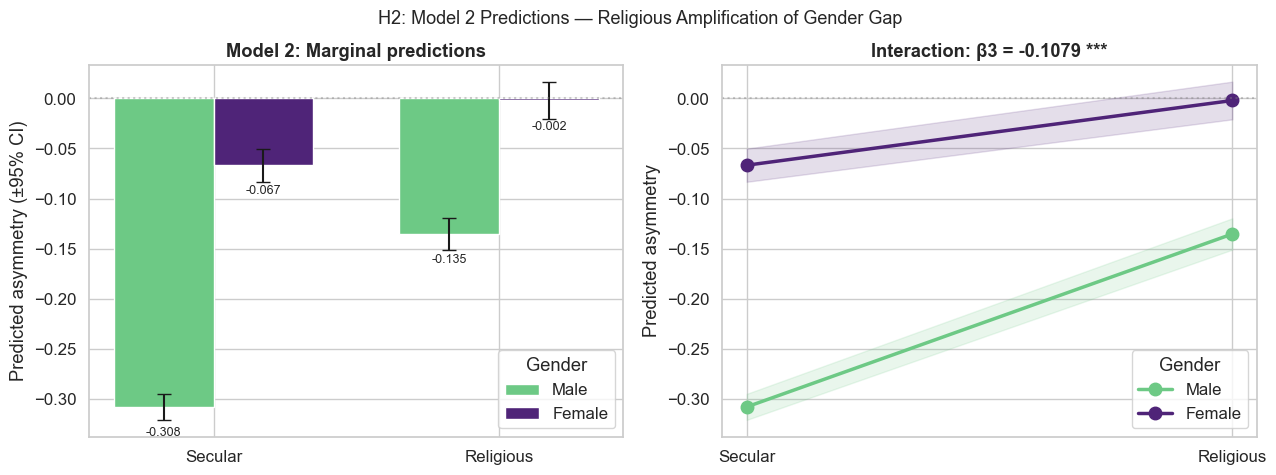

In [25]:
# ── 3c. Marginal predictions plot with CIs ──
from statsmodels.sandbox.predict_functional import predict_functional

# Build prediction grid manually
pred_grid = pd.DataFrame({
    "female":    [0, 0, 1, 1],
    "religious": [0, 1, 0, 1],
    "gender":    ["Male", "Male", "Female", "Female"],
    "context":   ["Secular", "Religious", "Secular", "Religious"],
})

# Get predicted values + SEs
pred_results = model2.get_prediction(pred_grid[["female", "religious"]])
pred_summary = pred_results.summary_frame(alpha=0.05)
pred_grid["pred"]  = pred_summary["mean"].values
pred_grid["ci_lo"] = pred_summary["mean_ci_lower"].values
pred_grid["ci_hi"] = pred_summary["mean_ci_upper"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: grouped bars (4 cells)
ctx_order = ["Secular", "Religious"]
x = np.arange(2)
w = 0.35
for j, g in enumerate(["Male", "Female"]):
    sub = pred_grid[pred_grid["gender"]==g].set_index("context")
    vals = [sub.loc[c, "pred"] for c in ctx_order]
    errs_lo = [sub.loc[c, "pred"] - sub.loc[c, "ci_lo"] for c in ctx_order]
    errs_hi = [sub.loc[c, "ci_hi"] - sub.loc[c, "pred"] for c in ctx_order]
    bars = axes[0].bar(x + j*w, vals, w, label=g, color=COLORS[g],
                       edgecolor="white",
                       yerr=[errs_lo, errs_hi],
                       capsize=5, error_kw={"elinewidth": 1.5})
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     v + (0.01 if v >= 0 else -0.029),
                     f"{v:.3f}", ha="center", fontsize=9)

axes[0].set_xticks(x + w/2)
axes[0].set_xticklabels(ctx_order)
axes[0].set_ylabel("Predicted asymmetry (±95% CI)")
axes[0].set_title("Model 2: Marginal predictions", fontweight="bold")
axes[0].axhline(0, color="gray", ls=":", alpha=0.4)
axes[0].legend(title="Gender")

# Panel 2: Interaction line plot
for g in ["Male", "Female"]:
    sub = pred_grid[pred_grid["gender"]==g].set_index("context")
    vals = [sub.loc[c, "pred"] for c in ctx_order]
    lo   = [sub.loc[c, "ci_lo"] for c in ctx_order]
    hi   = [sub.loc[c, "ci_hi"] for c in ctx_order]
    axes[1].plot(ctx_order, vals, "o-", color=COLORS[g], lw=2.5, ms=9, label=g)
    axes[1].fill_between(ctx_order, lo, hi, color=COLORS[g], alpha=0.15)

axes[1].axhline(0, color="gray", ls=":", alpha=0.4)
axes[1].set_ylabel("Predicted asymmetry")
axes[1].set_title(f"Interaction: β3 = {b3:+.4f} {sig_stars(pvals['female:religious'])}",
                  fontweight="bold")
axes[1].legend(title="Gender")

plt.suptitle("H2: Model 2 Predictions — Religious Amplification of Gender Gap",
             fontsize=13, y=0.95)
plt.tight_layout()
savefig(fig, "h2_03_model2_predictions")
plt.show()

---
## 4. Robustness: Warmth and Competence as Separate DVs

In [26]:
# ── 4a. Run Model 2 for all three outcomes ──
OUTCOMES = [
    ("asymmetry",          "Asymmetry (W−C)"),
    ("dirmean_Warmth",     "Warmth"),
    ("dirmean_Competence", "Competence"),
]

robustness_rows = []

print("=" * 70)
print("ROBUSTNESS: Model 2 across outcomes (β₃ = Female × Religious)")
print("=" * 70)

models_robust = {}
for col, label in OUTCOMES:
    m = smf.ols(f"{col} ~ female * religious", data=dfa).fit(cov_type="HC3")
    models_robust[label] = m
    b3_ = m.params["female:religious"]
    ci_  = m.conf_int().loc["female:religious"]
    p_   = m.pvalues["female:religious"]

    # All 4 marginal predictions
    b0_ = m.params["Intercept"]
    b1_ = m.params["female"]
    b2_ = m.params["religious"]

    robustness_rows.append({
        "Outcome": label,
        "β₁ (Female, secular)": round(b1_, 4),
        "β₂ (Religious, male)": round(b2_, 4),
        "β₃ (F×R interaction)": round(b3_, 4),
        "CI_lo": round(ci_.iloc[0], 4),
        "CI_hi": round(ci_.iloc[1], 4),
        "p-value": f"{p_:.3e}",
        "sig": sig_stars(p_),
        "Pred: M-Sec":  round(b0_, 4),
        "Pred: F-Sec":  round(b0_+b1_, 4),
        "Pred: M-Rel":  round(b0_+b2_, 4),
        "Pred: F-Rel":  round(b0_+b1_+b2_+b3_, 4),
        "R²": round(m.rsquared, 4),
    })

    print(f"\n  {label}:  β₃ = {b3_:+.4f}  [CI: {ci_.iloc[0]:+.4f}, {ci_.iloc[1]:+.4f}]  p={p_:.3e} {sig_stars(p_)}")

df_robust = pd.DataFrame(robustness_rows).set_index("Outcome")
print("\n")
display(df_robust)

ROBUSTNESS: Model 2 across outcomes (β₃ = Female × Religious)

  Asymmetry (W−C):  β₃ = -0.1079  [CI: -0.1402, -0.0757]  p=5.385e-11 ***

  Warmth:  β₃ = +0.0100  [CI: -0.0134, +0.0334]  p=4.013e-01 ns

  Competence:  β₃ = +0.1231  [CI: +0.0974, +0.1489]  p=7.696e-21 ***




,"β₁ (Female, secular)","β₂ (Religious, male)",β₃ (F×R interaction),CI_lo,CI_hi,p-value,sig,Pred: M-Sec,Pred: F-Sec,Pred: M-Rel,Pred: F-Rel,R²
Outcome,,,,,,,,,,,,
Asymmetry (W−C),0.2411,0.1725,-0.1079,-0.1402,-0.0757,5.385e-11,***,-0.3078,-0.0667,-0.1353,-0.0021,0.0463
Warmth,0.1181,0.0883,0.0100,-0.0134,0.0334,4.013e-01,ns,0.3194,0.4375,0.4077,0.5358,0.0325
Competence,-0.1297,-0.0840,0.1231,0.0974,0.1489,7.696e-21,***,0.6190,0.4893,0.5350,0.5284,0.0151


  Saved: ../figures/h2_04_robustness_coef_plot.png


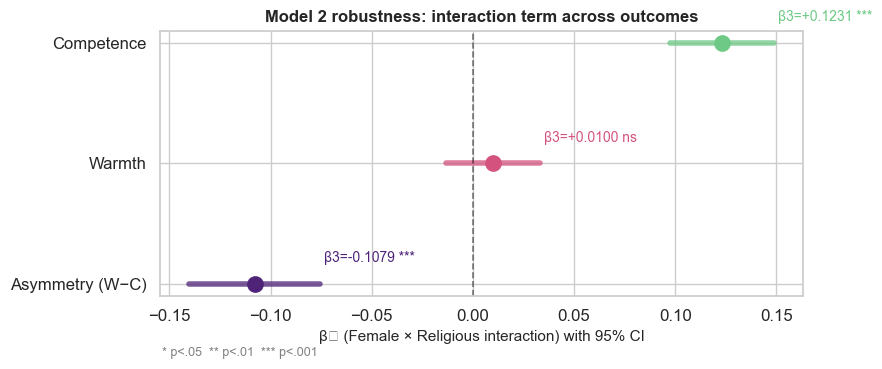

In [28]:
# ── 4b. Coefficient plot: β₃ across all outcomes ──
fig, ax = plt.subplots(figsize=(9, 4))

plot_colors_rob = ["#4f2478", "#D4537E", "#6dc985"]
y_labels = [r["Outcome"] for r in robustness_rows]

for i, (row, col) in enumerate(zip(robustness_rows, plot_colors_rob)):
    b = row["β₃ (F×R interaction)"]
    lo, hi = row["CI_lo"], row["CI_hi"]
    p = float(row["p-value"])

    ax.plot([lo, hi], [i, i], lw=4, color=col, alpha=0.75, solid_capstyle="round")
    ax.plot(b, i, "o", ms=11, color=col, zorder=5)
    ax.text(hi + 0.002, i + 0.18,
            f"β3={b:+.4f} {sig_stars(p)}", fontsize=10, color=col)

ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.5)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=12)
ax.set_xlabel("β₃ (Female × Religious interaction) with 95% CI", fontsize=11)
ax.set_title("Model 2 robustness: interaction term across outcomes",
             fontsize=12, fontweight="bold")
ax.text(ax.get_xlim()[0]+0.001, -0.6,
        "* p<.05  ** p<.01  *** p<.001", fontsize=9, color="gray")

plt.tight_layout()
savefig(fig, "h2_04_robustness_coef_plot")
plt.show()

---
## 5. Subfacet Breakdown: Which SADCAT Dimensions Drive the Pattern?

In [29]:
# ── 5a. Run Model 2 for every SADCAT subfacet ──
subfacet_rows = []

for dim in SUBFACETS:
    col = f"dirmean_{dim}"
    if col not in dfa.columns:
        continue
    m = smf.ols(f"{col} ~ female * religious", data=dfa).fit(cov_type="HC3")
    b3_ = m.params.get("female:religious", np.nan)
    ci_  = m.conf_int().loc["female:religious"] if "female:religious" in m.params.index else pd.Series([np.nan, np.nan])
    p_   = m.pvalues.get("female:religious", np.nan)
    b1_  = m.params.get("female", np.nan)

    subfacet_rows.append({
        "Dimension": dim,
        "β₁ (Female effect, secular)": round(b1_, 4),
        "β₃ (F×R interaction)": round(b3_, 4),
        "CI_lo": round(ci_.iloc[0], 4),
        "CI_hi": round(ci_.iloc[1], 4),
        "p-value": p_,
        "sig": sig_stars(p_),
    })

df_subfacets = pd.DataFrame(subfacet_rows).set_index("Dimension")
df_subfacets_sorted = df_subfacets.sort_values("β₃ (F×R interaction)", ascending=False)

print("=" * 70)
print("β₃ (Female × Religious) across ALL SADCAT dimensions")
print("=" * 70)
display(df_subfacets_sorted[["β₃ (F×R interaction)", "CI_lo", "CI_hi", "p-value", "sig"]].round(4))

β₃ (Female × Religious) across ALL SADCAT dimensions


,β₃ (F×R interaction),CI_lo,CI_hi,p-value,sig
Dimension,,,,,
Assertiveness,0.1562,0.1093,0.2030,0.0000,***
Competence,0.1231,0.0974,0.1489,0.0000,***
Sociability,0.0490,0.0201,0.0779,0.0009,***
Morality,0.0327,-0.0002,0.0656,0.0516,ns
Religion,0.0200,-0.0089,0.0489,0.1754,ns
Ability,0.0127,0.0015,0.0239,0.0257,*
Status,0.0118,-0.0142,0.0379,0.3739,ns
Warmth,0.0100,-0.0134,0.0334,0.4013,ns
Politics,-0.0732,-0.1409,-0.0054,0.0344,*


  Saved: ../figures/h2_05_subfacet_forest.png


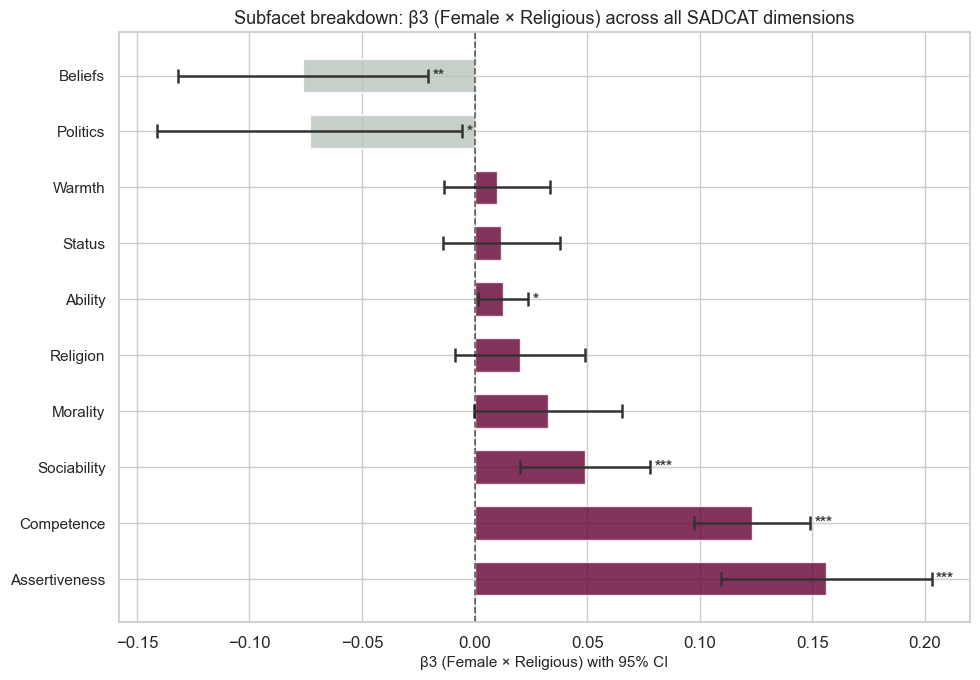

In [51]:
# ── 5b. Subfacet forest plot ──
fig, ax = plt.subplots(figsize=(10, 7))

dims_plot  = df_subfacets_sorted.index.tolist()
b3_vals    = df_subfacets_sorted["β₃ (F×R interaction)"].values
ci_lo_vals = df_subfacets_sorted["CI_lo"].values
ci_hi_vals = df_subfacets_sorted["CI_hi"].values
p_vals_sub = df_subfacets_sorted["p-value"].values

colors_sub = ["#660033" if b > 0 else "#B8C4BB" for b in b3_vals]
y_pos = np.arange(len(dims_plot))

ax.barh(y_pos, b3_vals,
        xerr=np.array([b3_vals - ci_lo_vals, ci_hi_vals - b3_vals]),
        height=0.6, color=colors_sub, alpha=0.8, capsize=5,
        error_kw={"elinewidth": 1.8, "capthick": 1.8, "ecolor": "#333"})

for i, (b, p) in enumerate(zip(b3_vals, p_vals_sub)):
    s = sig_stars(p)
    if s != "ns":
        offset = ci_hi_vals[i] + 0.002
        ax.text(offset, i, s, va="center", fontsize=11, fontweight="bold", color="#333")

ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(dims_plot, fontsize=11)
ax.set_xlabel("β3 (Female × Religious) with 95% CI", fontsize=11)
ax.set_title("Subfacet breakdown: β3 (Female × Religious) across all SADCAT dimensions",
             fontsize=13)
ax.annotate("← Religious attenuates female effect", xy=(ax.get_xlim()[0]+0.001, -0.8),
            fontsize=9, color="gray")
ax.annotate("Religious amplifies female effect →", xy=(0.002, -0.8),
            fontsize=9, color="gray")

plt.tight_layout()
savefig(fig, "h2_05_subfacet_forest")
plt.show()

---
## 6. Religious Sub-Genre Analysis

In [32]:
# ── 6a. Derive religious sub-genre from titulo/tags ──
# The dataset likely has a 'titulo' or tags column from the Prado iconography
# We classify religious artworks into sub-genres using keyword matching

religious_only = dfa[dfa["context"] == "religious"].copy()

# Check what text columns are available for sub-genre derivation
text_cols = [c for c in dfa.columns if any(kw in c.lower()
             for kw in ["titulo", "title", "tag", "tema", "theme", "subject", "iconog", "descrip"])]
print("Text columns available for sub-genre:", text_cols)
print(f"\nReligious figures: {len(religious_only):,}")
print(f"Columns in dataset: {list(dfa.columns)}")

Text columns available for sub-genre: ['descriptor_text', 'descriptor_length', 'n_descriptors', 'titulo']

Religious figures: 7,750
Columns in dataset: ['id', 'cat_no', 'context', 'figure_num', 'gender', 'qualifier', 'descriptor_text', 'descriptor_length', 'word_count', 'n_descriptors', 'n_in_dict', 'coverage_pct', 'dirmean_Warmth', 'dirmean_Competence', 'dirmean_Sociability', 'dirmean_Morality', 'dirmean_Ability', 'dirmean_Assertiveness', 'dirmean_Status', 'dirmean_Beliefs', 'dirmean_health', 'dirmean_deviance', 'dirmean_beauty', 'dirmean_Politics', 'dirmean_Religion', 'n_dirmean_Warmth', 'n_dirmean_Competence', 'n_dirmean_Sociability', 'n_dirmean_Morality', 'n_dirmean_Ability', 'n_dirmean_Assertiveness', 'n_dirmean_Status', 'n_dirmean_Beliefs', 'n_dirmean_health', 'n_dirmean_deviance', 'n_dirmean_beauty', 'n_dirmean_Politics', 'n_dirmean_Religion', 'asymmetry', 'model_id', 'created_at', 'is_religious', 'is_fauna', 'tipo_objeto', 'titulo', 'autor', 'century', 'datacion', 'female', 're

In [33]:
# ── 6b. Build sub-genre from titulo (Spanish title keyword matching) ──
# Adjust 'titulo' to whatever column name exists in your dataset
TITLE_COL = "titulo"  # ← change if column is named differently (e.g. "title", "artwork_title")

SUBGENRE_KEYWORDS = {
    "Virgin / Mary": ["virgen", "madonna", "inmaculada", "asunción", "annunciaci",
                      "natividad", "purificación", "visitación", "inmaculad"],
    "Saints":        ["santo", "santa", "san ", "san.", "santos",
                      "mártir", "mártires", "apóstol", "evangelista"],
    "New Testament": ["cristo", "jesús", "jesus", "crucifixión", "resurrecci",
                      "pentecostés", "bautismo", "transfiguración", "última cena",
                      "getsemaní", "calvario", "epifanía", "adoración"],
    "Old Testament": ["moisés", "david", "salomón", "sansón", "noé", "ester",
                      "tobías", "judith", "holofernes", "isaac", "abraham",
                      "jacob", "josué", "lot", "génesis"],
    "Allegory / Angel": ["ángel", "angel", "arcángel", "arcangel", "gloria",
                         "alegoría", "divina", "inmortali", "eternidad"],
}

def classify_subgenre(title):
    if pd.isna(title):
        return "Other Religious"
    t = str(title).lower()
    for genre, keywords in SUBGENRE_KEYWORDS.items():
        if any(kw in t for kw in keywords):
            return genre
    return "Other Religious"

if TITLE_COL in dfa.columns:
    religious_only = religious_only.copy()
    religious_only["subgenre"] = religious_only[TITLE_COL].apply(classify_subgenre)

    print("Sub-genre distribution (religious artworks):")
    sg_counts = religious_only.groupby("subgenre").agg(
        n_figures=("cat_no", "count"),
        n_artworks=("cat_no", "nunique"),
    ).sort_values("n_figures", ascending=False)
    print(sg_counts)
else:
    print(f"Column '{TITLE_COL}' not found. Available columns:")
    print([c for c in dfa.columns])
    print("\n→ Adjust TITLE_COL above to match your dataset.")

Sub-genre distribution (religious artworks):
                  n_figures  n_artworks
subgenre                               
Saints                 2649         898
Other Religious        1972         535
Virgin / Mary          1312         346
New Testament          1241         296
Old Testament           523         124
Allegory / Angel         53          12


Gender gap (F−M) in asymmetry per religious sub-genre:
  New Testament            : +0.1765
  Old Testament            : +0.1445
  Other Religious          : +0.1763
  Saints                   : +0.1426
  Virgin / Mary            : -0.0269
  Saved: ../figures/h2_06_subgenre_asymmetry.png


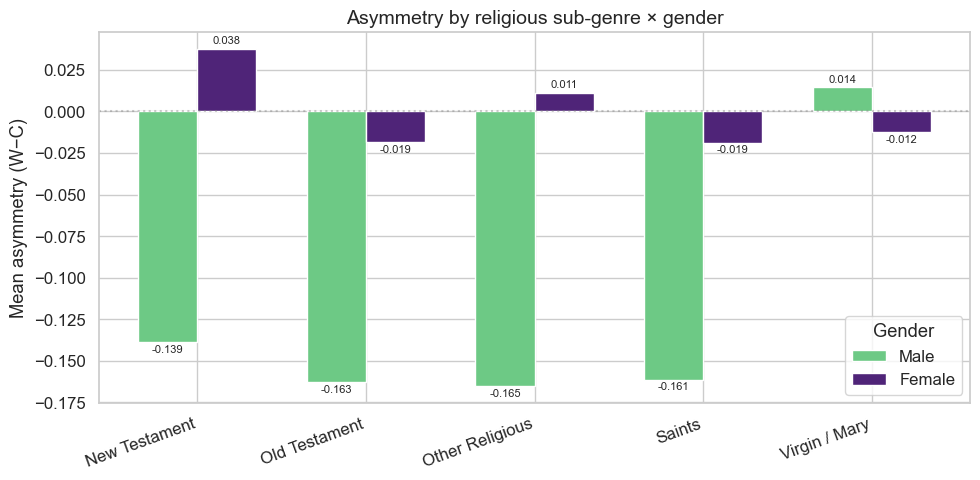


Welch t-test (gender) within each sub-genre:
  New Testament            : Δ=+0.1765, d=+0.332, p=1.229e-08 ***
  Old Testament            : Δ=+0.1445, d=+0.281, p=1.573e-03 **
  Other Religious          : Δ=+0.1763, d=+0.325, p=2.001e-11 ***
  Saints                   : Δ=+0.1426, d=+0.278, p=1.927e-10 ***
  Virgin / Mary            : Δ=-0.0269, d=-0.050, p=3.648e-01 ns


In [61]:
# ── 6c. Asymmetry by sub-genre × gender ──
if "subgenre" in religious_only.columns:
    # Keep sub-genres with enough figures per gender for meaningful comparison
    min_n = 30
    sg_gender = religious_only.groupby(["subgenre", "gender"]).agg(
        n=("cat_no", "count"),
        asymmetry=("asymmetry", "mean"),
        warmth=("dirmean_Warmth", "mean"),
        competence=("dirmean_Competence", "mean"),
    ).reset_index()

    valid_sgs = sg_gender.groupby("subgenre")["n"].min()
    valid_sgs = valid_sgs[valid_sgs >= min_n].index.tolist()

    sg_plot = sg_gender[sg_gender["subgenre"].isin(valid_sgs)]

    # Gender gap per sub-genre
    print("Gender gap (F−M) in asymmetry per religious sub-genre:")
    for sg in sorted(valid_sgs):
        m_val = sg_gender[(sg_gender["subgenre"]==sg) & (sg_gender["gender"]=="Male")]["asymmetry"].values
        f_val = sg_gender[(sg_gender["subgenre"]==sg) & (sg_gender["gender"]=="Female")]["asymmetry"].values
        if len(m_val) and len(f_val):
            print(f"  {sg:25s}: {f_val[0]-m_val[0]:+.4f}")

    # Plot
    n_sgs = len(valid_sgs)
    fig, ax = plt.subplots(figsize=(max(10, n_sgs*2), 5))

    x = np.arange(n_sgs)
    w = 0.35
    sg_order = sorted(valid_sgs)

    for j, g in enumerate(["Male", "Female"]):
        sub = sg_plot[sg_plot["gender"]==g].set_index("subgenre")
        vals = [sub.loc[s, "asymmetry"] if s in sub.index else np.nan for s in sg_order]
        bars = ax.bar(x + j*w, vals, w, label=g, color=COLORS[g], edgecolor="white")
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2,
                        v + (0.003 if v >= 0 else -0.006),
                        f"{v:.3f}", ha="center", fontsize=8)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(sg_order, rotation=20, ha="right")
    ax.axhline(0, color="gray", ls=":", alpha=0.4)
    ax.set_ylabel("Mean asymmetry (W−C)")
    ax.set_title("Asymmetry by religious sub-genre × gender",
                 fontsize=14)
    ax.legend(title="Gender")

    plt.tight_layout()
    savefig(fig, "h2_06_subgenre_asymmetry")
    plt.show()

    # Statistical test per sub-genre
    print("\nWelch t-test (gender) within each sub-genre:")
    for sg in sg_order:
        m_sub = religious_only[(religious_only["subgenre"]==sg) & (religious_only["gender"]=="Male")]["asymmetry"].dropna()
        f_sub = religious_only[(religious_only["subgenre"]==sg) & (religious_only["gender"]=="Female")]["asymmetry"].dropna()
        if len(m_sub) >= 10 and len(f_sub) >= 10:
            t_, p_ = stats.ttest_ind(f_sub, m_sub, equal_var=False)
            d_ = cohens_d(f_sub, m_sub)
            print(f"  {sg:25s}: Δ={f_sub.mean()-m_sub.mean():+.4f}, d={d_:+.3f}, p={p_:.3e} {sig_stars(p_)}")
else:
    print("Sub-genre column not built — run cell 6b first with correct TITLE_COL.")

---
## 7. Within-Artwork Paired Analysis by Context

In [35]:
# ── 7a. Build within-artwork paired dataset ──
artwork_genders = dfa.groupby("cat_no")["gender"].apply(set).reset_index()
artwork_genders["has_both"] = artwork_genders["gender"].apply(
    lambda s: "Male" in s and "Female" in s)
both_cat_nos = artwork_genders[artwork_genders["has_both"]]["cat_no"]
df_both = dfa[dfa["cat_no"].isin(both_cat_nos)].copy()

within_scores = df_both.groupby(["cat_no", "gender"]).agg(
    warmth=("dirmean_Warmth", "mean"),
    competence=("dirmean_Competence", "mean"),
    asymmetry=("asymmetry", "mean"),
).reset_index()

within_wide = within_scores.pivot(
    index="cat_no", columns="gender",
    values=["warmth", "competence", "asymmetry"]
)
within_wide.columns = [f"{d}_{g}" for d, g in within_wide.columns]
within_wide = within_wide.dropna().reset_index()

for col in ["warmth", "competence", "asymmetry"]:
    within_wide[f"{col}_diff"] = within_wide[f"{col}_Female"] - within_wide[f"{col}_Male"]

# Merge context (take first context if mixed — most artworks are one context)
within_ctx = within_wide.merge(
    dfa[["cat_no", "context"]].drop_duplicates(subset="cat_no"),
    on="cat_no"
)

print(f"Mixed-gender artworks: {len(within_ctx):,}")
print(within_ctx.groupby("context").size().rename("n_artworks"))

Mixed-gender artworks: 2,720
context
religious    1240
secular      1480
Name: n_artworks, dtype: int64


In [36]:
# ── 7b. Is the within-painting gender gap larger in religious artworks? ──
print("=" * 65)
print("WITHIN-ARTWORK PAIRED ANALYSIS: Gap (F−M) by context")
print("=" * 65)

within_results = []
for col, label in [("asymmetry_diff", "Asymmetry"),
                   ("warmth_diff",    "Warmth"),
                   ("competence_diff","Competence")]:
    rel = within_ctx[within_ctx["context"]=="religious"][col].dropna()
    sec = within_ctx[within_ctx["context"]=="secular"][col].dropna()

    t_, p_ = stats.ttest_ind(rel, sec, equal_var=False)
    d_ = cohens_d(rel, sec)

    within_results.append({
        "Outcome": label,
        "Religious mean": rel.mean(),
        "Secular mean":   sec.mean(),
        "Diff (Rel−Sec)": rel.mean() - sec.mean(),
        "Cohen's d": d_,
        "Welch t": t_, "p-value": p_, "sig": sig_stars(p_),
    })

    print(f"\n  {label}:")
    print(f"    Within-religious gap (F−M): {rel.mean():+.4f} (n_artworks={len(rel)})")
    print(f"    Within-secular  gap (F−M):  {sec.mean():+.4f} (n_artworks={len(sec)})")
    print(f"    Diff (Rel−Sec): {rel.mean()-sec.mean():+.4f}  d={d_:+.3f}  p={p_:.3e} {sig_stars(p_)}")

df_within = pd.DataFrame(within_results).set_index("Outcome")

WITHIN-ARTWORK PAIRED ANALYSIS: Gap (F−M) by context

  Asymmetry:
    Within-religious gap (F−M): +0.0893 (n_artworks=1240)
    Within-secular  gap (F−M):  +0.2548 (n_artworks=1480)
    Diff (Rel−Sec): -0.1655  d=-0.271  p=2.700e-12 ***

  Warmth:
    Within-religious gap (F−M): +0.1299 (n_artworks=1240)
    Within-secular  gap (F−M):  +0.1354 (n_artworks=1480)
    Diff (Rel−Sec): -0.0055  d=-0.013  p=7.256e-01 ns

  Competence:
    Within-religious gap (F−M): +0.0399 (n_artworks=1240)
    Within-secular  gap (F−M):  -0.1258 (n_artworks=1480)
    Diff (Rel−Sec): +0.1657  d=+0.313  p=1.748e-15 ***


  Saved: ../figures/h2_07_within_artwork_by_context.png


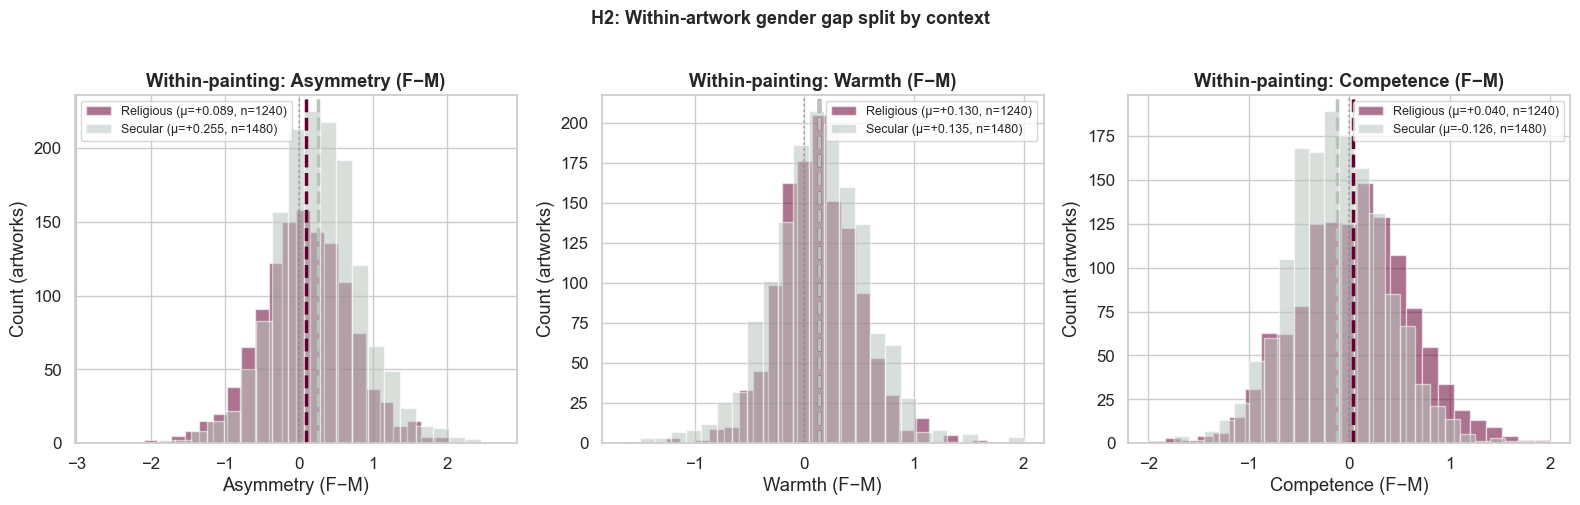

In [37]:
# ── 7c. Paired gap distribution by context ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label) in zip(axes, [
    ("asymmetry_diff", "Asymmetry (F−M)"),
    ("warmth_diff",    "Warmth (F−M)"),
    ("competence_diff","Competence (F−M)"),
]):
    for ctx in ["religious", "secular"]:
        vals = within_ctx[within_ctx["context"]==ctx][col].dropna()
        ax.hist(vals, bins=25, alpha=0.55,
                label=f"{ctx.capitalize()} (μ={vals.mean():+.3f}, n={len(vals)})",
                color=CTX_COLORS[ctx], edgecolor="white")
        ax.axvline(vals.mean(), color=CTX_COLORS[ctx], lw=2.5, ls="--")

    ax.axvline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Count (artworks)")
    ax.set_title(f"Within-painting: {label}", fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("H2: Within-artwork gender gap split by context",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
savefig(fig, "h2_07_within_artwork_by_context")
plt.show()

---
## 8. Sensitivity Checks

In [38]:
# ── 8a. Coverage filter: exclude figures with <30% SADCAT coverage ──
dfa_filtered = dfa[dfa["coverage_pct"] >= 30].copy()
print(f"Coverage ≥30%: {len(dfa_filtered):,} figures ({len(dfa_filtered)/len(dfa)*100:.1f}% of original)")

m2_filtered = smf.ols("asymmetry ~ female * religious",
                       data=dfa_filtered).fit(cov_type="HC3")
b3_filtered = m2_filtered.params["female:religious"]
p3_filtered = m2_filtered.pvalues["female:religious"]
ci3_filtered = m2_filtered.conf_int().loc["female:religious"]

print(f"\nModel 2 (coverage ≥30%):")
print(f"  β₃ = {b3_filtered:+.4f}  [CI: {ci3_filtered.iloc[0]:+.4f}, {ci3_filtered.iloc[1]:+.4f}]")
print(f"  p   = {p3_filtered:.3e} {sig_stars(p3_filtered)}")
print(f"\nOriginal Model 2:")
b3_orig = model2.params["female:religious"]
print(f"  β₃ = {b3_orig:+.4f}")
print(f"\n→ Change in β₃: {b3_filtered - b3_orig:+.4f} ({(b3_filtered-b3_orig)/abs(b3_orig)*100:+.1f}%)")

Coverage ≥30%: 18,646 figures (99.4% of original)

Model 2 (coverage ≥30%):
  β₃ = -0.1082  [CI: -0.1404, -0.0759]
  p   = 4.815e-11 ***

Original Model 2:
  β₃ = -0.1079

→ Change in β₃: -0.0002 (-0.2%)


In [44]:
# ── 8b. Century control: add C(century_bin) as fixed effect ──
dfa_cent = dfa[dfa["century_num"].notna()].copy()
dfa_cent = dfa.dropna(subset=["asymmetry"]).copy()

# Bin into broader periods for stable estimation
def century_bin(c):
    if c <= 15: return "≤15th"
    elif c == 16: return "16th"
    elif c == 17: return "17th"
    elif c == 18: return "18th"
    else: return "19th+"

dfa_cent["century_bin"] = dfa_cent["century_num"].apply(century_bin)

print(f"Figures with century: {len(dfa_cent):,} ({len(dfa_cent)/len(dfa)*100:.1f}%)")
print(dfa_cent["century_bin"].value_counts().sort_index())

# Model 2 + century fixed effects
m2_century = smf.ols(
    "asymmetry ~ female * religious + C(century_bin)",
    data=dfa_cent
).fit(cov_type="HC3")

b3_c = m2_century.params["female:religious"]
p3_c = m2_century.pvalues["female:religious"]
ci3_c = m2_century.conf_int().loc["female:religious"]

print(f"\nModel 2 + Century FE:")
print(f"  β₃ = {b3_c:+.4f}  [CI: {ci3_c.iloc[0]:+.4f}, {ci3_c.iloc[1]:+.4f}]")
print(f"  p   = {p3_c:.3e} {sig_stars(p3_c)}")
print(f"\n→ Change vs baseline: {b3_c - b3_orig:+.4f}")
print(f"  Interpretation: {'β₃ survives century control — not a temporal confound.' if p3_c < 0.05 else 'β₃ weakened after century control — partial confound.'}")

Figures with century: 17,773 (94.7%)
century_bin
16th     2117
17th     7505
18th     2662
19th+    4741
≤15th     748
Name: count, dtype: int64

Model 2 + Century FE:
  β₃ = -0.1050  [CI: -0.1372, -0.0727]
  p   = 1.796e-10 ***

→ Change vs baseline: +0.0029
  Interpretation: β₃ survives century control — not a temporal confound.


---
## 9. Clustered Standard Errors by Artwork

In [45]:
dfa_clean = dfa.dropna(subset=["asymmetry"]).copy()

m2_clustered = smf.ols("asymmetry ~ female * religious", data=dfa_clean).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_clean["cat_no"]}
)

print("Model 2 — Clustered SEs (by artwork):")
print(f"  β₃ = {m2_clustered.params['female:religious']:+.4f}")
ci = m2_clustered.conf_int().loc["female:religious"]
print(f"  95% CI: [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"  p = {m2_clustered.pvalues['female:religious']:.2e}")

Model 2 — Clustered SEs (by artwork):
  β₃ = -0.1079
  95% CI: [-0.1430, -0.0729]
  p = 1.56e-09


In [47]:
dfa_cent = dfa_cent[dfa_cent["century_num"].notna()]

m2_full = smf.ols("asymmetry ~ female * religious + C(century_num)", data=dfa_cent).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_cent["cat_no"]}
)

print("Most conservative — Model 2 + Century FE + Clustered:")
print(f"  β₃ = {m2_full.params['female:religious']:+.4f}")
ci = m2_full.conf_int().loc["female:religious"]
print(f"  95% CI: [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"  p = {m2_full.pvalues['female:religious']:.2e}")

Most conservative — Model 2 + Century FE + Clustered:
  β₃ = -0.1048
  95% CI: [-0.1399, -0.0697]
  p = 4.87e-09


In [63]:
print("H2 ROBUSTNESS SUMMARY")
print("=" * 70)

specs = [
    ("OLS + HC3 (primary)", model2),
    ("OLS + Clustered SE", m2_clustered),
    ("OLS + HC3 + Century FE", m2_century),  # from cell 30
    ("OLS + Clustered + Century FE", m2_full),
]

rows = []
for label, m in specs:
    b3 = m.params["female:religious"]
    ci = m.conf_int().loc["female:religious"]
    p = m.pvalues["female:religious"]
    rows.append({
        "Specification": label,
        "β₃ (F×R)": f"{b3:+.4f}",
        "95% CI": f"[{ci[0]:+.4f}, {ci[1]:+.4f}]",
        "p-value": f"{p:.2e}",
        "R²": f"{m.rsquared:.4f}",
    })

robustness_df = pd.DataFrame(rows)
print(robustness_df.to_string(index=False))

H2 ROBUSTNESS SUMMARY
               Specification β₃ (F×R)             95% CI  p-value     R²
         OLS + HC3 (primary)  -0.1079 [-0.1402, -0.0757] 5.39e-11 0.0463
          OLS + Clustered SE  -0.1079 [-0.1430, -0.0729] 1.56e-09 0.0463
      OLS + HC3 + Century FE  -0.1050 [-0.1372, -0.0727] 1.80e-10 0.0482
OLS + Clustered + Century FE  -0.1048 [-0.1399, -0.0697] 4.87e-09 0.0483


---
## 10. H2 Results Summary

In [ ]:
# ── 10. Full H2 summary ──
print("=" * 80)
print("H2 RESULTS SUMMARY")
print("Hypothesis: Gender gap in W−C asymmetry is LARGER in religious artworks")
print("=" * 80)

# Model 2 key results
b0_ = model2.params["Intercept"]
b1_ = model2.params["female"]
b2_ = model2.params["religious"]
b3_ = model2.params["female:religious"]
p3_ = model2.pvalues["female:religious"]
ci3_ = model2.conf_int().loc["female:religious"]

print(f"\nModel 2 (HC3 robust SEs):")
print(f"  β₁ (Female effect, secular):    {b1_:+.4f}")
print(f"  β₂ (Religious effect, male):    {b2_:+.4f}")
print(f"  β₃ (Female × Religious):         {b3_:+.4f}  [CI: {ci3_.iloc[0]:+.4f}, {ci3_.iloc[1]:+.4f}]  p={p3_:.3e} {sig_stars(p3_)}")
print(f"  R²: {model2.rsquared:.4f}  |  N: {int(model2.nobs):,}")

print(f"\nMarginal predictions (all 4 cells):")
cells = {
    "Male, Secular":   b0_,
    "Female, Secular": b0_+b1_,
    "Male, Religious": b0_+b2_,
    "Female, Religious": b0_+b1_+b2_+b3_,
}
for k, v in cells.items():
    print(f"  {k:25s}: {v:+.4f}")

gap_sec = (b0_+b1_) - b0_
gap_rel = (b0_+b1_+b2_+b3_) - (b0_+b2_)
print(f"\nGender gap — Secular:   {gap_sec:+.4f}")
print(f"Gender gap — Religious: {gap_rel:+.4f}")
print(f"Amplification (β₃):     {b3_:+.4f}")


print()
print("VERDICT:")
if b3_ > 0 and p3_ < 0.05:
    print("  ✓ H2 SUPPORTED: Religious context significantly amplifies the female W−C asymmetry.")
elif p3_ >= 0.05:
    print("  ✗ H2 NOT SUPPORTED: No significant interaction between gender and religious context.")
elif b3_ < 0:
    print("  ~ H2 REVERSED: Religious context reduces (not amplifies) the gender gap.")

H2 RESULTS SUMMARY
Hypothesis: Gender gap in W−C asymmetry is LARGER in religious artworks

Model 2 (HC3 robust SEs):
  β₁ (Female effect, secular):    +0.2411
  β₂ (Religious effect, male):    +0.1725
  β₃ (Female × Religious):         -0.1079  [CI: -0.1402, -0.0757]  p=5.385e-11 ***
  R²: 0.0463  |  N: 17,773

Marginal predictions (all 4 cells):
  Male, Secular            : -0.3078
  Female, Secular          : -0.0667
  Male, Religious          : -0.1353
  Female, Religious        : -0.0021

Gender gap — Secular:   +0.2411
Gender gap — Religious: +0.1332
Amplification (β₃):     -0.1079

VERDICT:
  ~ H2 REVERSED: Religious context attenuates (not amplifies) the gender gap.
